# Sysmon CSV Exploratory Data Analysis

## 📖 Overview

This notebook performs comprehensive exploratory data analysis on the processed Sysmon CSV file generated from the JSONL-to-CSV preprocessing step. The goal is to understand data quality, distributions, patterns, and characteristics that will inform our causal event search algorithm improvements.

### 🎯 Analysis Objectives

1. **Data Quality Assessment**: Missing values, data types, consistency
2. **Event Distribution Analysis**: EventID patterns, temporal distributions
3. **Process Relationship Mapping**: GUID/PID patterns, parent-child relationships
4. **Temporal Analysis**: Time patterns, event clustering, duration analysis
5. **Security Pattern Detection**: Suspicious activities, anomalous behaviors
6. **Data Integrity Validation**: GUID consistency, PID reuse detection
7. **Algorithm Input Assessment**: Data readiness for causal chain analysis

---

## 🛠️ Step 1: Required Libraries

Import essential libraries for data analysis and visualization:

In [41]:
# ================================================================================
# Step 1: IMPORTS AND SETUP
# ================================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import re
from collections import Counter
import json
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


## 📁 Step 1b: Data Loading

Load the processed Sysmon CSV file and perform initial inspection:

In [42]:
# ================================================================================
# Step 1b: ANALYSIS CONFIGURATION
# ================================================================================

# Target dataset configuration
TARGET_PATH = "../dataset/run-01-apt-1/"
TARGET_FILE = "02_sysmon-run-01.csv"
TARGET_FILEPATH = os.path.join(TARGET_PATH, TARGET_FILE)

print(f"Target CSV: {TARGET_FILEPATH}")
print(f"File exists: {os.path.exists(TARGET_FILEPATH)}")

# Define explicit data types for proper CSV reading
dtype_spec = {
    # Integer columns that might have NaN values - use nullable Int64
    'ProcessId': 'Int64',
    'SourcePort': 'Int64', 
    'DestinationPort': 'Int64',
    'SourceProcessId': 'Int64',
    'ParentProcessId': 'Int64',
    'SourceThreadId': 'Int64',
    'TargetProcessId': 'Int64',
    
    # GUID columns - ensure string type
    'ProcessGuid': 'string',
    'SourceProcessGUID': 'string',
    'TargetProcessGUID': 'string', 
    'ParentProcessGuid': 'string',
    
    # Categorical columns for memory efficiency
    'Computer': 'category',
    'Protocol': 'category',
    'EventType': 'category'
}

try:
    df = pd.read_csv(TARGET_FILEPATH, low_memory=False, dtype=dtype_spec)
    print(f"\n✅ Successfully loaded {len(df):,} records with correct data types")
    print(f"📊 Dataset shape: {df.shape}")
    print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Verify data types were applied correctly
    print(f"\n🔍 Data Type Verification:")
    integer_cols = ['ProcessId', 'SourcePort', 'DestinationPort', 'SourceProcessId', 'ParentProcessId']
    for col in integer_cols:
        if col in df.columns:
            sample_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
            print(f"  {col}: {df[col].dtype} (sample: {sample_val})")
    
    guid_cols = ['ProcessGuid', 'SourceProcessGUID', 'TargetProcessGUID', 'ParentProcessGuid']
    for col in guid_cols:
        if col in df.columns:
            sample_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
            has_brackets = str(sample_val).startswith('{') if sample_val != 'N/A' else False
            print(f"  {col}: {df[col].dtype} (sample: {sample_val}, has_brackets: {has_brackets})")
            
except Exception as e:
    print(f"❌ Error loading CSV: {e}")
    df = None

Target CSV: ../dataset/run-01-apt-1/02_sysmon-run-01.csv
File exists: True

✅ Successfully loaded 363,657 records with correct data types
📊 Dataset shape: (363657, 45)
💾 Memory usage: 525.57 MB

🔍 Data Type Verification:
  ProcessId: Int64 (sample: 1212)
  SourcePort: Int64 (sample: 5355)
  DestinationPort: Int64 (sample: 63060)
  SourceProcessId: Int64 (sample: 644)
  ParentProcessId: Int64 (sample: 2220)
  ProcessGuid: string (sample: 44d66c27-4e6d-67da-1c00-000000007000, has_brackets: False)
  SourceProcessGUID: string (sample: 3fc4fefd-4f23-67da-0c00-000000004700, has_brackets: False)
  TargetProcessGUID: string (sample: 3fc4fefd-4f29-67da-6d00-000000004700, has_brackets: False)
  ParentProcessGuid: string (sample: 44d66c27-4e6d-67da-3400-000000007000, has_brackets: False)


## 🔍 Step 2: Basic Data Inspection

Examine the structure, data types, and basic statistics:

In [43]:
# ================================================================================
# Step 2: DATASET OVERVIEW
# ================================================================================

if df is not None:
    print("📋 DATASET OVERVIEW")
    print("=" * 50)
    print(f"Rows: {len(df):,}")
    print(f"Columns: {len(df.columns)}")
    print(f"\nColumn names:")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:2}. {col}")
    
    print(f"\n🔢 DATA TYPES SUMMARY")
    print("=" * 30)
    print(df.dtypes.value_counts())
    
    print(f"\n📊 BASIC STATISTICS")
    print("=" * 30)
    print(f"EventID range: {df['EventID'].min()} - {df['EventID'].max()}")
    print(f"Unique EventIDs: {df['EventID'].nunique()}")
    print(f"Unique computers: {df['Computer'].nunique()}")
    print(f"Computer names: {list(df['Computer'].unique())}")

📋 DATASET OVERVIEW
Rows: 363,657
Columns: 45

Column names:
   1. EventID
   2. Computer
   3. EventType
   4. ProcessGuid
   5. ProcessId
   6. Image
   7. TargetObject
   8. User
   9. SourceProcessGUID
  10. SourceProcessId
  11. SourceImage
  12. TargetProcessGUID
  13. TargetProcessId
  14. TargetImage
  15. SourceThreadId
  16. SourceUser
  17. TargetUser
  18. TargetFilename
  19. CreationUtcTime
  20. CommandLine
  21. CurrentDirectory
  22. Hashes
  23. ParentProcessGuid
  24. ParentProcessId
  25. ParentImage
  26. ParentCommandLine
  27. PipeName
  28. ImageLoaded
  29. OriginalFileName
  30. Device
  31. Protocol
  32. SourceIsIpv6
  33. SourceIp
  34. SourceHostname
  35. SourcePort
  36. SourcePortName
  37. DestinationIsIpv6
  38. DestinationIp
  39. DestinationHostname
  40. DestinationPort
  41. DestinationPortName
  42. PreviousCreationUtcTime
  43. NewThreadId
  44. Hash
  45. timestamp

🔢 DATA TYPES SUMMARY
object            28
Int64              7
string[python]   

In [44]:
# ================================================================================
# Step 2b: SAMPLE DATA DISPLAY
# ================================================================================

# Display first few rows
if df is not None:
    print("📄 SAMPLE DATA (First 3 rows)")
    print("=" * 40)
    display(df.head(3))

📄 SAMPLE DATA (First 3 rows)


,EventID,Computer,EventType,ProcessGuid,ProcessId,Image,TargetObject,User,SourceProcessGUID,SourceProcessId,SourceImage,TargetProcessGUID,TargetProcessId,TargetImage,SourceThreadId,SourceUser,TargetUser,TargetFilename,CreationUtcTime,CommandLine,CurrentDirectory,Hashes,ParentProcessGuid,ParentProcessId,ParentImage,ParentCommandLine,PipeName,ImageLoaded,OriginalFileName,Device,Protocol,SourceIsIpv6,SourceIp,SourceHostname,SourcePort,SourcePortName,DestinationIsIpv6,DestinationIp,DestinationHostname,DestinationPort,DestinationPortName,PreviousCreationUtcTime,NewThreadId,Hash,timestamp
0,3,endofroad.boombox.local,NaN,44d66c27-4e6d-67da-1c00-000000007000,1212,C:\Windows\System32\svchost.exe,NaN,NT AUTHORITY\NETWORK SERVICE,<NA>,<NA>,NaN,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,udp,True,ff02:0:0:0:0:0:1:3,-,5355,llmnr,True,fe80:0:0:0:f92b:28da:7976:fd5a,theblock,63060,-,NaN,NaN,NaN,1742360400346
1,3,endofroad.boombox.local,NaN,44d66c27-4e6d-67da-1c00-000000007000,1212,C:\Windows\System32\svchost.exe,NaN,NT AUTHORITY\NETWORK SERVICE,<NA>,<NA>,NaN,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,udp,False,224.0.0.252,-,5355,llmnr,False,10.1.0.5,theblock.boombox.local,63060,-,NaN,NaN,NaN,1742360400346
2,3,endofroad.boombox.local,NaN,44d66c27-4e6d-67da-1c00-000000007000,1212,C:\Windows\System32\svchost.exe,NaN,NT AUTHORITY\NETWORK SERVICE,<NA>,<NA>,NaN,<NA>,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,udp,False,224.0.0.252,-,5355,llmnr,False,10.1.0.6,WATERFALLS.boombox.local,54211,-,NaN,NaN,NaN,1742360400690


In [45]:
# ================================================================================
# Step 2c: DETAILED DATA TYPES ANALYSIS
# ================================================================================

# Data types analysis
if df is not None:
    print("🔍 DETAILED DATA TYPES ANALYSIS")
    print("=" * 45)
    
    dtype_info = []
    for col in df.columns:
        dtype_info.append({
            'Column': col,
            'Data_Type': str(df[col].dtype),
            'Non_Null_Count': df[col].count(),
            'Null_Count': df[col].isnull().sum(),
            'Null_Percentage': (df[col].isnull().sum() / len(df)) * 100,
            'Unique_Values': df[col].nunique(),
            'Sample_Value': str(df[col].dropna().iloc[0]) if not df[col].dropna().empty else 'N/A'
        })
    
    dtype_df = pd.DataFrame(dtype_info)
    display(dtype_df)

🔍 DETAILED DATA TYPES ANALYSIS


,Column,Data_Type,Non_Null_Count,Null_Count,Null_Percentage,Unique_Values,Sample_Value
0,EventID,int64,363657,0,0.000000,20,3
1,Computer,category,363657,0,0.000000,4,endofroad.boombox.local
2,EventType,category,157237,206420,56.762279,6,SetValue
3,ProcessGuid,string,248846,114811,31.571233,1633,44d66c27-4e6d-67da-1c00-000000007000
4,ProcessId,Int64,248846,114811,31.571233,1240,1212
5,Image,object,248846,114811,31.571233,356,C:\Windows\System32\svchost.exe
6,TargetObject,object,155513,208144,57.236352,36681,HKLM\System\CurrentControlSet\Control\WMI\Auto...
7,User,object,248844,114813,31.571783,17,NT AUTHORITY\NETWORK SERVICE
8,SourceProcessGUID,string,114742,248915,68.447741,493,3fc4fefd-4f23-67da-0c00-000000004700
9,SourceProcessId,Int64,114742,248915,68.447741,447,644


## 📈 Step 3: Event Distribution Analysis

Analyze the distribution of different Sysmon event types:

In [46]:
# ================================================================================
# Step 3: EVENT TYPE DISTRIBUTION
# ================================================================================

if df is not None:
    # EventID distribution
    print("📊 EVENT TYPE DISTRIBUTION")
    print("=" * 35)
    
    # Event descriptions for context
    event_descriptions = {
        1: 'Process Create',
        2: 'File Creation Time',
        3: 'Network Connection',
        4: 'Sysmon State Change',
        5: 'Process Terminate',
        6: 'Driver Load',
        7: 'Image Load',
        8: 'Create Remote Thread',
        9: 'Raw Access Read',
        10: 'Process Access',
        11: 'File Create',
        12: 'Registry Event (Object create/delete)',
        13: 'Registry Event (Value set)',
        14: 'Registry Event (Key/Value rename)',
        15: 'File Create Stream Hash',
        17: 'Pipe Create',
        18: 'Pipe Connect',
        19: 'WMI Event Filter',
        20: 'WMI Event Consumer',
        21: 'WMI Event Consumer To Filter',
        22: 'DNS Event',
        23: 'File Delete',
        24: 'Clipboard Change',
        25: 'Process Tampering'
    }
    
    event_counts = df['EventID'].value_counts().sort_index()
    event_percentages = df['EventID'].value_counts(normalize=True).sort_index() * 100
    
    print(f"{'EventID':<8} {'Description':<35} {'Count':<10} {'Percentage':<10}")
    print("-" * 70)
    
    for event_id in event_counts.index:
        desc = event_descriptions.get(event_id, 'Unknown Event')
        count = event_counts[event_id]
        pct = event_percentages[event_id]
        print(f"{event_id:<8} {desc:<35} {count:<10,} {pct:<10.2f}%")

📊 EVENT TYPE DISTRIBUTION
EventID  Description                         Count      Percentage
----------------------------------------------------------------------
1        Process Create                      1,023      0.28      %
2        File Creation Time                  212        0.06      %
3        Network Connection                  14,424     3.97      %
4        Sysmon State Change                 1          0.00      %
5        Process Terminate                   900        0.25      %
6        Driver Load                         67         0.02      %
7        Image Load                          56,875     15.64     %
8        Create Remote Thread                6          0.00      %
9        Raw Access Read                     1,170      0.32      %
10       Process Access                      114,736    31.55     %
11       File Create                         6,782      1.86      %
12       Registry Event (Object create/delete) 109,413    30.09     %
13       Registry 

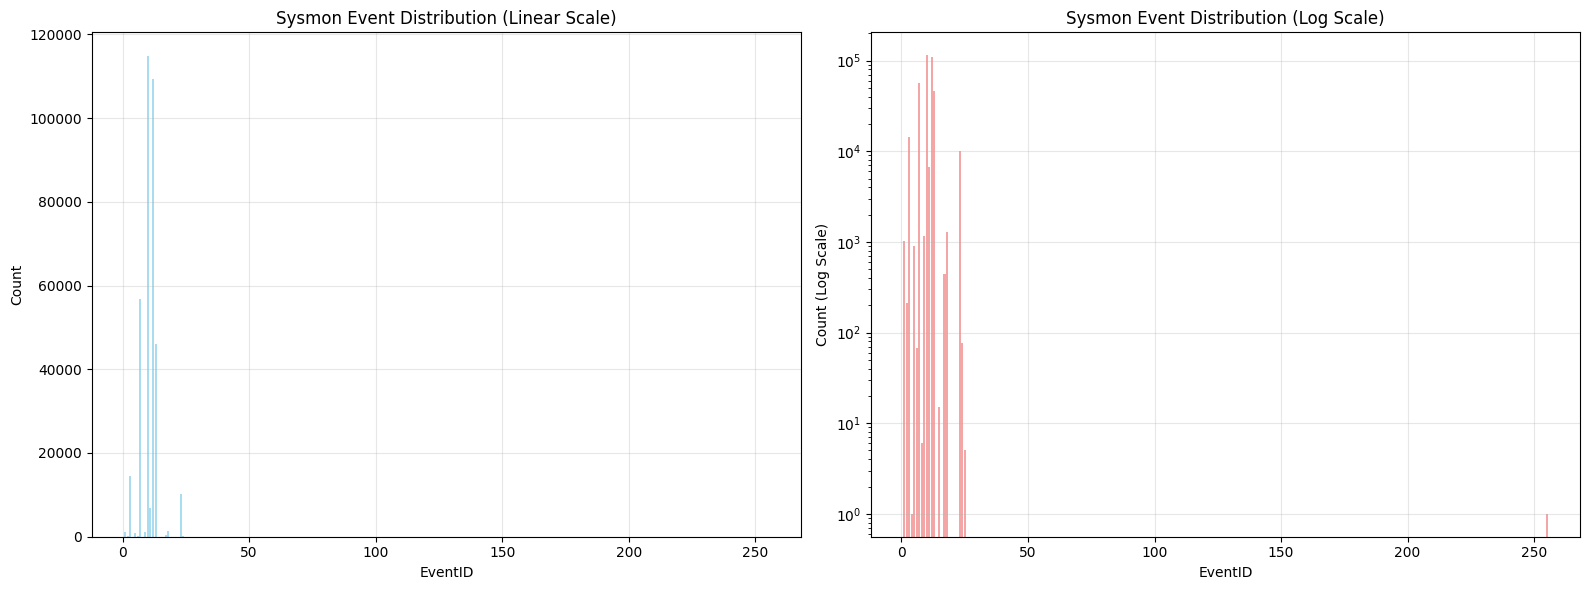

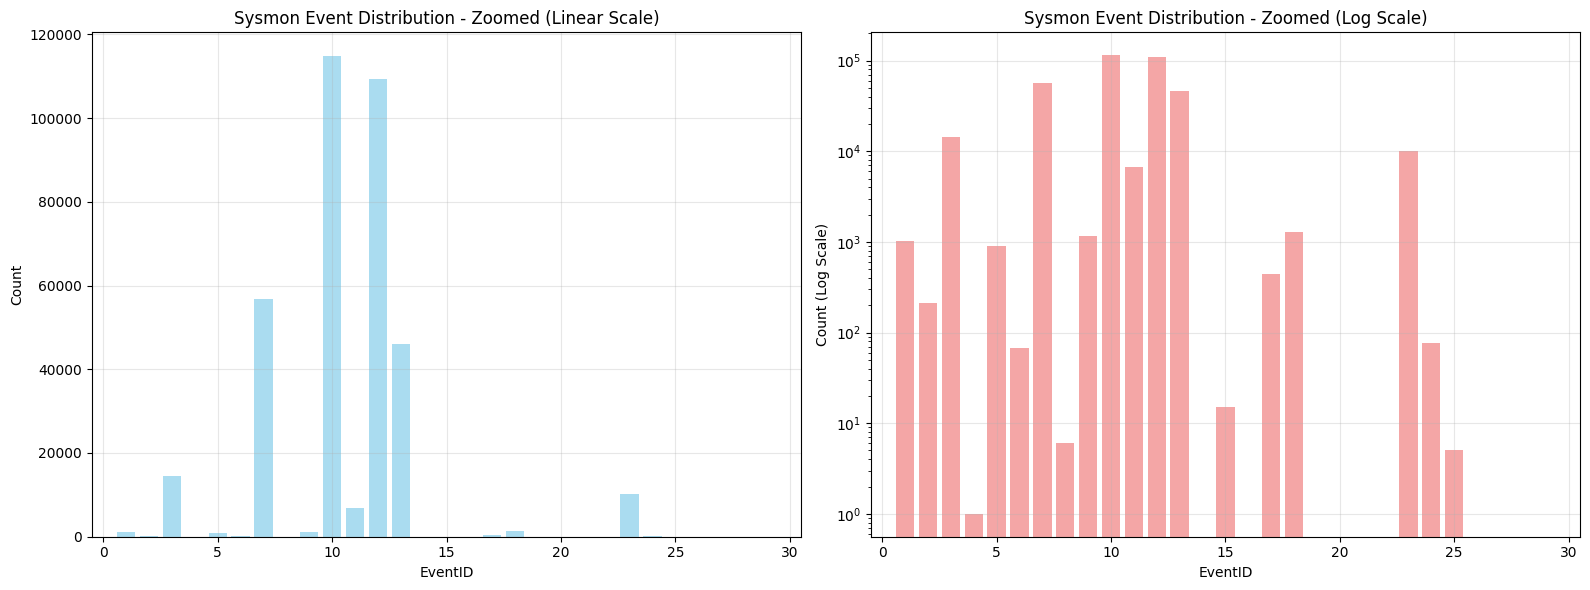


🔝 TOP 10 MOST COMMON EVENTS
EventID 10: Process Access - 114,736 events (31.6%)
EventID 12: Registry Event (Object create/delete) - 109,413 events (30.1%)
EventID 7: Image Load - 56,875 events (15.6%)
EventID 13: Registry Event (Value set) - 46,100 events (12.7%)
EventID 3: Network Connection - 14,424 events (4.0%)
EventID 23: File Delete - 10,126 events (2.8%)
EventID 11: File Create - 6,782 events (1.9%)
EventID 18: Pipe Connect - 1,280 events (0.4%)
EventID 9: Raw Access Read - 1,170 events (0.3%)
EventID 1: Process Create - 1,023 events (0.3%)


In [47]:
# ================================================================================
# Step 3b: EVENT DISTRIBUTION VISUALIZATION
# ================================================================================

# Visualize event distribution
if df is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart of event counts
    event_counts = df['EventID'].value_counts().sort_index()
    ax1.bar(event_counts.index, event_counts.values, alpha=0.7, color='skyblue')
    ax1.set_xlabel('EventID')
    ax1.set_ylabel('Count')
    ax1.set_title('Sysmon Event Distribution (Linear Scale)')
    ax1.grid(True, alpha=0.3)
    
    # Log scale for better visibility
    ax2.bar(event_counts.index, event_counts.values, alpha=0.7, color='lightcoral')
    ax2.set_xlabel('EventID')
    ax2.set_ylabel('Count (Log Scale)')
    ax2.set_title('Sysmon Event Distribution (Log Scale)')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Zoomed view: EventID 0-30 (excluding outlier EventID 255)
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))
    
    event_counts_zoomed = event_counts[event_counts.index <= 30]
    
    ax3.bar(event_counts_zoomed.index, event_counts_zoomed.values, alpha=0.7, color='skyblue')
    ax3.set_xlabel('EventID')
    ax3.set_ylabel('Count')
    ax3.set_title('Sysmon Event Distribution - Zoomed (Linear Scale)')
    ax3.set_xlim(-0.5, 30.5)
    ax3.grid(True, alpha=0.3)
    
    ax4.bar(event_counts_zoomed.index, event_counts_zoomed.values, alpha=0.7, color='lightcoral')
    ax4.set_xlabel('EventID')
    ax4.set_ylabel('Count (Log Scale)')
    ax4.set_title('Sysmon Event Distribution - Zoomed (Log Scale)')
    ax4.set_yscale('log')
    ax4.set_xlim(-0.5, 30.5)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Top 10 most common events
    print("\n🔝 TOP 10 MOST COMMON EVENTS")
    print("=" * 35)
    top_events = df['EventID'].value_counts().head(10)
    for event_id, count in top_events.items():
        desc = event_descriptions.get(event_id, 'Unknown')
        pct = (count / len(df)) * 100
        print(f"EventID {event_id}: {desc} - {count:,} events ({pct:.1f}%)")

## ⏰ Step 4: Temporal Analysis

Analyze timing patterns and temporal distributions:

In [48]:
# ================================================================================
# Step 4: TEMPORAL ANALYSIS
# ================================================================================

if df is not None:
    # The CSV has 'timestamp' (epoch ms) instead of 'UtcTime'
    # Convert epoch milliseconds to datetime
    if 'timestamp' in df.columns:
        df['UtcTime'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
        
        print("⏰ TEMPORAL ANALYSIS")
        print("=" * 25)
        print(f"Source column: 'timestamp' (epoch ms, int64)")
        print(f"Converted to: 'UtcTime' (datetime64)")
        
        # Basic time statistics
        valid_times = df['UtcTime'].dropna()
        if len(valid_times) > 0:
            print(f"\nTime range: {valid_times.min()} to {valid_times.max()}")
            duration = valid_times.max() - valid_times.min()
            print(f"Total duration: {duration}")
            print(f"Events with valid timestamps: {len(valid_times):,} ({len(valid_times)/len(df)*100:.1f}%)")
            print(f"Events without timestamps: {df['UtcTime'].isnull().sum():,}")
            
            # Events per minute/hour statistics
            events_per_second = len(valid_times) / duration.total_seconds()
            events_per_minute = events_per_second * 60
            events_per_hour = events_per_minute * 60
            
            print(f"\n📊 Event Rate Statistics:")
            print(f"Events per second: {events_per_second:.2f}")
            print(f"Events per minute: {events_per_minute:.2f}")
            print(f"Events per hour: {events_per_hour:.2f}")
        else:
            print("⚠️ No valid timestamps found after conversion")
    else:
        print("⚠️ 'timestamp' column not found in DataFrame")

⏰ TEMPORAL ANALYSIS
Source column: 'timestamp' (epoch ms, int64)
Converted to: 'UtcTime' (datetime64)

Time range: 2025-03-19 05:00:00.346000 to 2025-03-19 06:12:02.599000
Total duration: 0 days 01:12:02.253000
Events with valid timestamps: 363,655 (100.0%)
Events without timestamps: 2

📊 Event Rate Statistics:
Events per second: 84.14
Events per minute: 5048.13
Events per hour: 302887.87


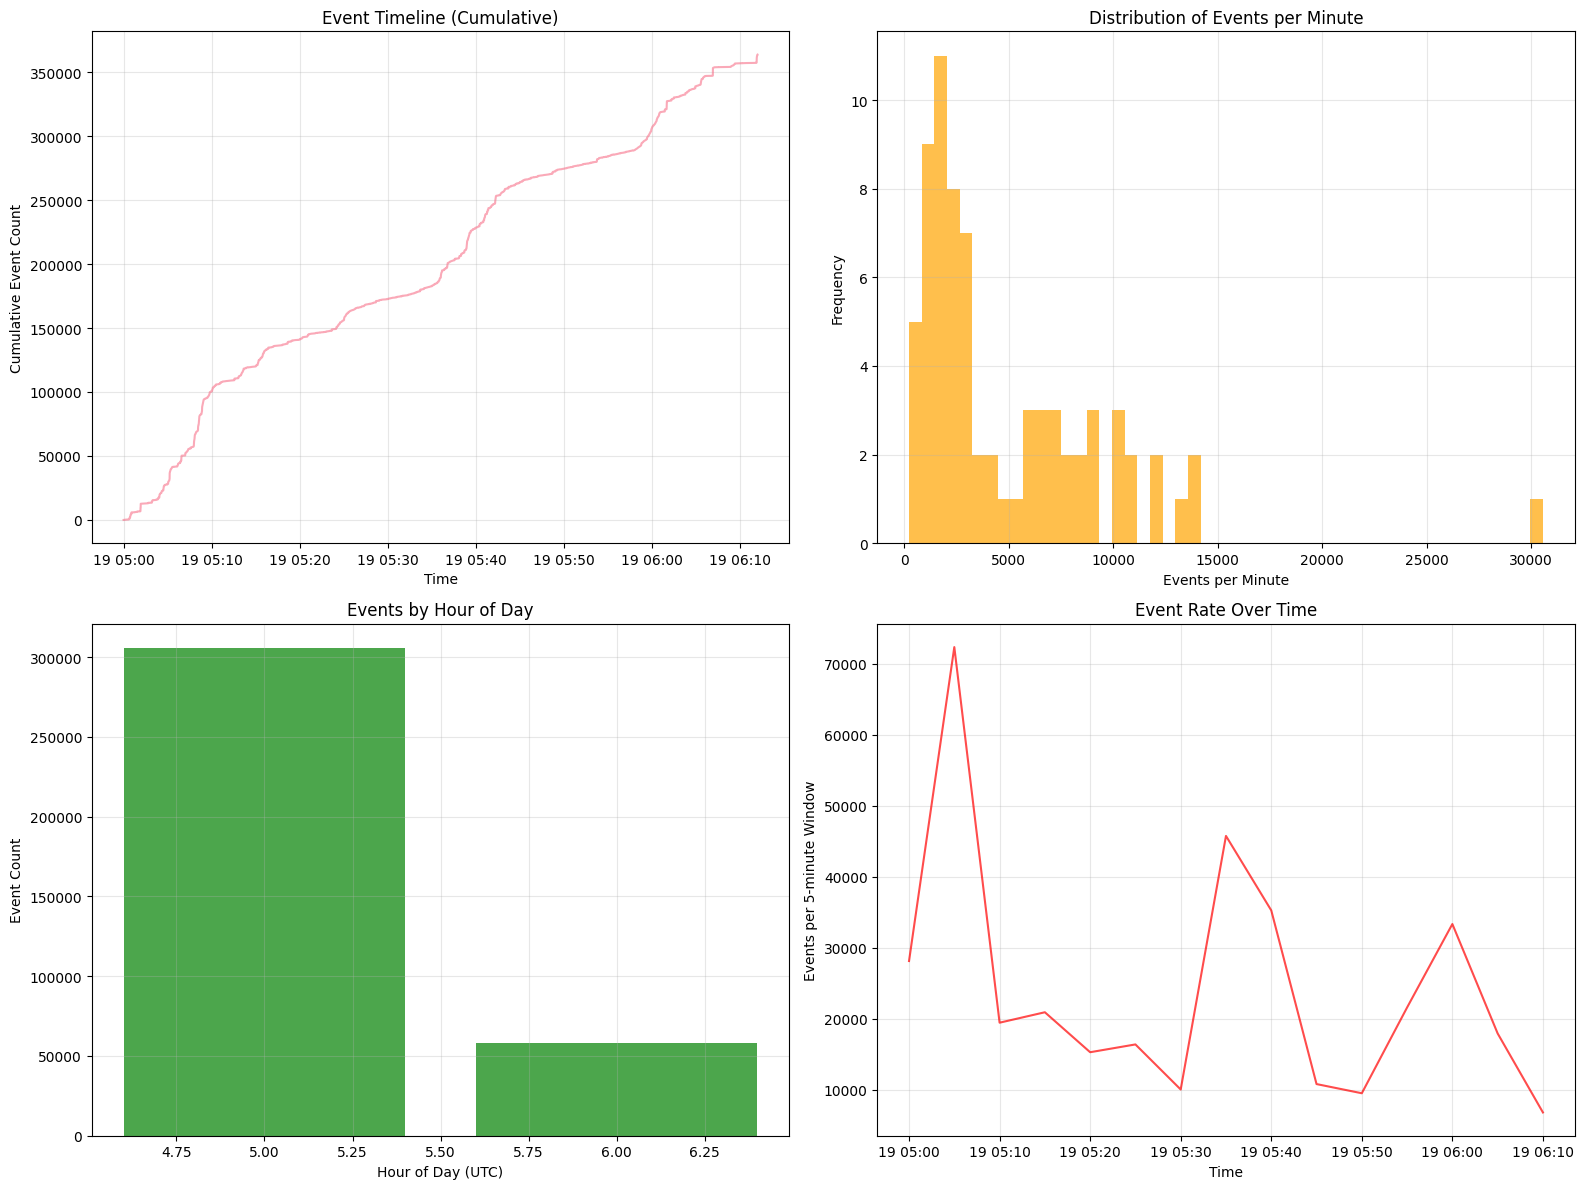


📈 Temporal Patterns Summary:
Peak events per minute: 30563
Average events per minute: 4981.6
Busiest hour: 5:00 UTC (305,542 events)
Quietest hour: 6:00 UTC (58,113 events)


In [49]:
# ================================================================================
# Step 4b: TEMPORAL VISUALIZATION
# ================================================================================

# Temporal visualization
if df is not None and 'UtcTime' in df.columns:  # Created from 'timestamp' in SECTION 5
    valid_times = df['UtcTime'].dropna()
    
    if len(valid_times) > 0:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Timeline of all events
        df_time_sorted = df[df['UtcTime'].notna()].sort_values('UtcTime')
        ax1.plot(df_time_sorted['UtcTime'], range(len(df_time_sorted)), alpha=0.6)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Cumulative Event Count')
        ax1.set_title('Event Timeline (Cumulative)')
        ax1.grid(True, alpha=0.3)
        
        # 2. Events per minute histogram
        df_resampled = df_time_sorted.set_index('UtcTime').resample('1T').size()
        ax2.hist(df_resampled.values, bins=50, alpha=0.7, color='orange')
        ax2.set_xlabel('Events per Minute')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Distribution of Events per Minute')
        ax2.grid(True, alpha=0.3)
        
        # 3. Hourly pattern
        df_time_sorted['Hour'] = df_time_sorted['UtcTime'].dt.hour
        hourly_counts = df_time_sorted['Hour'].value_counts().sort_index()
        ax3.bar(hourly_counts.index, hourly_counts.values, alpha=0.7, color='green')
        ax3.set_xlabel('Hour of Day (UTC)')
        ax3.set_ylabel('Event Count')
        ax3.set_title('Events by Hour of Day')
        ax3.grid(True, alpha=0.3)
        
        # 4. Event rate over time (events per 5-minute window)
        event_rate = df_time_sorted.set_index('UtcTime').resample('5T').size()
        ax4.plot(event_rate.index, event_rate.values, alpha=0.7, color='red')
        ax4.set_xlabel('Time')
        ax4.set_ylabel('Events per 5-minute Window')
        ax4.set_title('Event Rate Over Time')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n📈 Temporal Patterns Summary:")
        print(f"Peak events per minute: {df_resampled.max()}")
        print(f"Average events per minute: {df_resampled.mean():.1f}")
        print(f"Busiest hour: {hourly_counts.idxmax()}:00 UTC ({hourly_counts.max():,} events)")
        print(f"Quietest hour: {hourly_counts.idxmin()}:00 UTC ({hourly_counts.min():,} events)")

## 🔗 Step 5: Process Relationship Analysis

Analyze process relationships, GUIDs, and PIDs for causal chain validation:

In [50]:
# ================================================================================
# Step 5: PROCESS RELATIONSHIP ANALYSIS
# ================================================================================

NULL_GUID = '00000000-0000-0000-0000-000000000000'

# Each tuple: (guid_col, pid_col, event_ids)
# event_ids=None means "all EventIDs except 8 and 10" (standard process events)
GUID_PID_PAIRS = [
    ('ProcessGuid',       'ProcessId',       None),
    ('ParentProcessGuid', 'ParentProcessId', [1]),
    ('SourceProcessGUID', 'SourceProcessId', [8, 10]),
    ('TargetProcessGUID', 'TargetProcessId', [8, 10]),
]

if df is not None:
    print("🔗 PROCESS RELATIONSHIP ANALYSIS")
    print("=" * 60)

    relationship_stats = {}

    for guid_col, pid_col, event_ids in GUID_PID_PAIRS:
        if guid_col not in df.columns or pid_col not in df.columns:
            continue

        # Restrict to the EventIDs where this pair is meaningful
        if event_ids is not None:
            subset = df[df['EventID'].isin(event_ids)]
        else:
            subset = df[~df['EventID'].isin([8, 10])]

        # Rows where both columns are populated
        valid = subset[subset[guid_col].notna() & subset[pid_col].notna()]

        # Separate sentinel rows from real GUIDs before counting
        sentinel_rows = valid[valid[guid_col] == NULL_GUID]
        real          = valid[valid[guid_col] != NULL_GUID]

        unique_guids = real[guid_col].nunique()
        unique_pids  = real[pid_col].nunique()
        unique_pairs = real.groupby([guid_col, pid_col]).size().shape[0]
        reuse_ratio  = unique_pairs / unique_pids if unique_pids > 0 else 0

        relationship_stats[guid_col] = {
            'valid_pairs':         len(valid),
            'sentinel_rows':       len(sentinel_rows),
            'unique_guids':        unique_guids,
            'unique_pids':         unique_pids,
            'unique_combinations': unique_pairs,
            'reuse_ratio':         reuse_ratio,
        }

        eid_label     = str(event_ids) if event_ids else 'todos excepto 8/10'
        sentinel_note = f"  ({len(sentinel_rows)} con centinela)" if len(sentinel_rows) > 0 else ""
        reuse_flag    = " ⚠️" if reuse_ratio > 1.1 else ""

        print(f"\n{guid_col} / {pid_col}:")
        print(f"  EventIDs:               {eid_label}")
        print(f"  Pares no nulos:         {len(valid):>8,}{sentinel_note}")
        print(f"  GUIDs reales únicos:    {unique_guids:>8,}")
        print(f"  PIDs únicos:            {unique_pids:>8,}")
        print(f"  Combinaciones GUID-PID: {unique_pairs:>8,}")
        print(f"  Ratio reuso PID:        {reuse_ratio:>8.2f}{reuse_flag}")


🔗 PROCESS RELATIONSHIP ANALYSIS

ProcessGuid / ProcessId:
  EventIDs:               todos excepto 8/10
  Pares no nulos:          248,846  (36 con centinela)
  GUIDs reales únicos:       1,632
  PIDs únicos:               1,240
  Combinaciones GUID-PID:    1,632
  Ratio reuso PID:            1.32 ⚠️

ParentProcessGuid / ParentProcessId:
  EventIDs:               [1]
  Pares no nulos:            1,023  (500 con centinela)
  GUIDs reales únicos:         234
  PIDs únicos:                 223
  Combinaciones GUID-PID:      234
  Ratio reuso PID:            1.05

SourceProcessGUID / SourceProcessId:
  EventIDs:               [8, 10]
  Pares no nulos:          114,742
  GUIDs reales únicos:         493
  PIDs únicos:                 447
  Combinaciones GUID-PID:      493
  Ratio reuso PID:            1.10 ⚠️

TargetProcessGUID / TargetProcessId:
  EventIDs:               [8, 10]
  Pares no nulos:          114,742  (4 con centinela)
  GUIDs reales únicos:       1,420
  PIDs únicos:          

## 👶 Step 5b: Process Creation Analysis (EventID 1)

In [40]:
# ================================================================================
# Step 5b: PROCESS CREATION ANALYSIS
# ================================================================================

# Process creation analysis (EventID 1)
if df is not None:
    process_creates = df[df['EventID'] == 1]
    
    if len(process_creates) > 0:
        print("\n👶 PROCESS CREATION ANALYSIS (EventID 1)")
        print("=" * 45)
        print(f"Total process creation events: {len(process_creates):,}")
        
        # Parent-child relationships
        valid_parent_child = process_creates[
            (process_creates['ParentProcessGuid'].notna()) & 
            (process_creates['ProcessGuid'].notna())
        ]
        
        print(f"Events with valid parent-child relationships: {len(valid_parent_child):,}")
        
        if len(valid_parent_child) > 0:
            # Find orphaned processes (no parent)
            orphaned = process_creates[process_creates['ParentProcessGuid'].isna()]
            print(f"Orphaned processes (no parent): {len(orphaned):,}")
            
            # Count children per parent
            children_per_parent = valid_parent_child['ParentProcessGuid'].value_counts()
            print(f"\nParent process statistics:")
            print(f"  Parents with children: {len(children_per_parent):,}")
            print(f"  Average children per parent: {children_per_parent.mean():.1f}")
            print(f"  Max children for single parent: {children_per_parent.max()}")
            print(f"  Parents with >10 children: {(children_per_parent > 10).sum()}")
            
            # Most prolific parents
            if len(children_per_parent) > 0:
                print(f"\n🏆 Most prolific parents (Top 5):")
                for parent_guid, child_count in children_per_parent.head(5).items():
                    parent_info = process_creates[process_creates['ProcessGuid'] == parent_guid]
                    if not parent_info.empty:
                        parent_image = parent_info['Image'].iloc[0] if 'Image' in parent_info.columns else 'Unknown'
                        print(f"  {child_count} children - {parent_image}")
                    else:
                        print(f"  {child_count} children - Parent not found in dataset")


👶 PROCESS CREATION ANALYSIS (EventID 1)
Total process creation events: 1,023
Events with valid parent-child relationships: 1,023
Orphaned processes (no parent): 0

Parent process statistics:
  Parents with children: 235
  Average children per parent: 4.4
  Max children for single parent: 500
  Parents with >10 children: 9

🏆 Most prolific parents (Top 5):
  500 children - Parent not found in dataset
  44 children - Parent not found in dataset
  31 children - C:\Users\Public\SystemFailureReporter.exe
  19 children - Parent not found in dataset
  19 children - C:\Program Files\Google\Chrome\Application\chrome.exe


## 💻 Step 5c: Command Line Analysis (EventID 1)

In [ ]:
# ================================================================================
# Step 5c: COMMAND LINE ANALYSIS
# ================================================================================

# Command line analysis
if df is not None and 'CommandLine' in df.columns:
    print("\n💻 COMMAND LINE ANALYSIS")
    print("=" * 30)
    
    cmd_data = df[df['CommandLine'].notna()]
    print(f"Events with command lines: {len(cmd_data):,} ({len(cmd_data)/len(df)*100:.1f}%)")
    
    if len(cmd_data) > 0:
        # Extract base commands (first word)
        cmd_data_copy = cmd_data.copy()
        cmd_data_copy['BaseCommand'] = cmd_data_copy['CommandLine'].str.split().str[0].str.lower()
        
        # Remove common prefixes
        cmd_data_copy['BaseCommand'] = cmd_data_copy['BaseCommand'].str.replace(r'.*\\', '', regex=True)
        
        top_commands = cmd_data_copy['BaseCommand'].value_counts().head(15)
        
        print(f"\n🔝 Most common base commands:")
        for cmd, count in top_commands.items():
            pct = (count / len(cmd_data)) * 100
            print(f"  {cmd}: {count:,} executions ({pct:.1f}%)")
        
        # Command line length analysis
        cmd_lengths = cmd_data['CommandLine'].str.len()
        print(f"\n📏 Command line length statistics:")
        print(f"  Average length: {cmd_lengths.mean():.1f} characters")
        print(f"  Median length: {cmd_lengths.median():.1f} characters")
        print(f"  Max length: {cmd_lengths.max()} characters")
        print(f"  Commands >500 chars: {(cmd_lengths > 500).sum()}")
        print(f"  Commands >1000 chars: {(cmd_lengths > 1000).sum()}")
        
        # Look for potentially suspicious patterns
        suspicious_patterns = {
            'PowerShell encoded': cmd_data['CommandLine'].str.contains('-EncodedCommand|-enc', case=False, na=False).sum(),
            'PowerShell execution policy bypass': cmd_data['CommandLine'].str.contains('-ExecutionPolicy Bypass', case=False, na=False).sum(),
            'Base64 patterns': cmd_data['CommandLine'].str.contains('base64|b64encode', case=False, na=False).sum(),
            'Download commands': cmd_data['CommandLine'].str.contains('wget|curl|Invoke-WebRequest|DownloadFile', case=False, na=False).sum(),
            'Script execution': cmd_data['CommandLine'].str.contains('\.ps1|\.bat|\.cmd|\.vbs', case=False, na=False).sum()
        }
        
        print(f"\n🚨 Potentially suspicious command patterns:")
        for pattern, count in suspicious_patterns.items():
            if count > 0:
                pct = (count / len(cmd_data)) * 100
                print(f"  {pattern}: {count} occurrences ({pct:.2f}%)")


💻 COMMAND LINE ANALYSIS
Events with command lines: 1,023 (0.3%)

🔝 Most common base commands:
  program: 239 executions (23.4%)
  svchost.exe: 94 executions (9.2%)
  conhost.exe: 70 executions (6.8%)
  dllhost.exe: 60 executions (5.9%)
  wmiprvse.exe: 50 executions (4.9%)
  cmd.exe: 41 executions (4.0%)
  taskhostw.exe: 40 executions (3.9%)
  backgroundtaskhost.exe": 35 executions (3.4%)
  runtimebroker.exe: 30 executions (2.9%)
  sppsvc.exe: 16 executions (1.6%)
  "netsh": 12 executions (1.2%)
  rundll32.exe": 12 executions (1.2%)
  net1: 9 executions (0.9%)
  dsregcmd.exe: 9 executions (0.9%)
  net: 9 executions (0.9%)

📏 Command line length statistics:
  Average length: 170.3 characters
  Median length: 59.0 characters
  Max length: 5584 characters
  Commands >500 chars: 46
  Commands >1000 chars: 14

🚨 Potentially suspicious command patterns:
  PowerShell execution policy bypass: 1 occurrences (0.10%)
  Download commands: 4 occurrences (0.39%)
  Script execution: 15 occurrences (1

## 🌐 Step 6: Network Activity Analysis

Analyze network connections and patterns (EventID 3):

In [32]:
# ================================================================================
# Step 6: NETWORK ACTIVITY ANALYSIS
# ================================================================================

if df is not None:
    network_events = df[df['EventID'] == 3]
    
    if len(network_events) > 0:
        print("🌐 NETWORK CONNECTION ANALYSIS (EventID 3)")
        print("=" * 50)
        print(f"Total network connection events: {len(network_events):,}")
        
        # Protocol distribution
        if 'Protocol' in network_events.columns:
            protocols = network_events['Protocol'].value_counts()
            print(f"\n📊 Protocol distribution:")
            for protocol, count in protocols.items():
                pct = (count / len(network_events)) * 100
                print(f"  {protocol}: {count:,} connections ({pct:.1f}%)")
        
        # Port analysis
        if 'DestinationPort' in network_events.columns:
            dest_ports = network_events['DestinationPort'].dropna()
            if len(dest_ports) > 0:
                top_ports = dest_ports.value_counts().head(15)
                print(f"\n🔌 Top destination ports:")
                
                # Common port mappings
                port_services = {
                    80: 'HTTP', 443: 'HTTPS', 53: 'DNS', 21: 'FTP', 22: 'SSH',
                    25: 'SMTP', 110: 'POP3', 143: 'IMAP', 993: 'IMAPS', 995: 'POP3S',
                    3389: 'RDP', 445: 'SMB', 135: 'RPC', 139: 'NetBIOS', 389: 'LDAP'
                }
                
                for port, count in top_ports.items():
                    service = port_services.get(int(port), 'Unknown')
                    pct = (count / len(dest_ports)) * 100
                    print(f"  Port {port} ({service}): {count:,} connections ({pct:.1f}%)")
        
        # IP address analysis
        if 'DestinationIp' in network_events.columns:
            dest_ips = network_events['DestinationIp'].dropna()
            unique_ips = dest_ips.nunique()
            print(f"\n🌍 IP address statistics:")
            print(f"  Unique destination IPs: {unique_ips:,}")
            
            if len(dest_ips) > 0:
                top_ips = dest_ips.value_counts().head(10)
                print(f"\n🎯 Top destination IPs:")
                for ip, count in top_ips.items():
                    pct = (count / len(dest_ips)) * 100
                    print(f"  {ip}: {count:,} connections ({pct:.1f}%)")
                
                # Check for private vs public IPs
                private_pattern = r'^(10\.|172\.(1[6-9]|2[0-9]|3[01])\.|192\.168\.|127\.0\.0\.1)'
                private_ips = dest_ips.str.match(private_pattern, na=False).sum()
                public_ips = len(dest_ips) - private_ips
                
                print(f"\n🏠 IP address classification:")
                print(f"  Private/Local IPs: {private_ips:,} ({private_ips/len(dest_ips)*100:.1f}%)")
                print(f"  Public IPs: {public_ips:,} ({public_ips/len(dest_ips)*100:.1f}%)")
    else:
        print("🌐 No network connection events found (EventID 3)")

🌐 NETWORK CONNECTION ANALYSIS (EventID 3)
Total network connection events: 14,424

📊 Protocol distribution:
  tcp: 8,813 connections (61.1%)
  udp: 5,611 connections (38.9%)

🔌 Top destination ports:
  Port 53 (DNS): 2,265 connections (15.7%)
  Port 443 (HTTPS): 2,121 connections (14.7%)
  Port 444 (Unknown): 1,378 connections (9.6%)
  Port 389 (LDAP): 1,099 connections (7.6%)
  Port 88 (Unknown): 819 connections (5.7%)
  Port 6001 (Unknown): 748 connections (5.2%)
  Port 81 (Unknown): 592 connections (4.1%)
  Port 80 (HTTP): 410 connections (2.8%)
  Port 5355 (Unknown): 240 connections (1.7%)
  Port 3268 (Unknown): 202 connections (1.4%)
  Port 890 (Unknown): 196 connections (1.4%)
  Port 135 (RPC): 180 connections (1.2%)
  Port 64337 (Unknown): 167 connections (1.2%)
  Port 64327 (Unknown): 160 connections (1.1%)
  Port 445 (SMB): 139 connections (1.0%)

🌍 IP address statistics:
  Unique destination IPs: 189

🎯 Top destination IPs:
  10.1.0.4: 3,572 connections (24.8%)
  fe80:0:0:0:f

## 📁 Step 7: File System Activity Analysis

Analyze file creation, deletion, and access patterns:

In [33]:
# ================================================================================
# Step 7: FILE SYSTEM ACTIVITY ANALYSIS
# ================================================================================

if df is not None:
    # File creation events (EventID 11)
    file_creates = df[df['EventID'] == 11]
    file_deletes = df[df['EventID'] == 23]
    
    print("📁 FILE SYSTEM ACTIVITY ANALYSIS")
    print("=" * 40)
    print(f"File creation events (EventID 11): {len(file_creates):,}")
    print(f"File deletion events (EventID 23): {len(file_deletes):,}")
    
    # Analyze file extensions for created files
    if len(file_creates) > 0 and 'TargetFilename' in file_creates.columns:
        target_files = file_creates['TargetFilename'].dropna()
        
        if len(target_files) > 0:
            # Extract file extensions
            extensions = target_files.str.extract(r'\.([^.\\]+)$')[0].str.lower()
            ext_counts = extensions.value_counts().head(15)
            
            print(f"\n📄 File creation by extension (Top 15):")
            for ext, count in ext_counts.items():
                pct = (count / len(target_files)) * 100
                print(f"  .{ext}: {count:,} files ({pct:.1f}%)")
            
            # Analyze file paths
            temp_files = target_files.str.contains(r'\\temp\\|\\tmp\\', case=False, na=False).sum()
            system_files = target_files.str.contains(r'\\system32\\|\\windows\\', case=False, na=False).sum()
            user_files = target_files.str.contains(r'\\users\\|\\home\\', case=False, na=False).sum()
            appdata_files = target_files.str.contains(r'\\appdata\\', case=False, na=False).sum()
            
            print(f"\n📍 File creation by location:")
            print(f"  Temp directories: {temp_files:,} ({temp_files/len(target_files)*100:.1f}%)")
            print(f"  System directories: {system_files:,} ({system_files/len(target_files)*100:.1f}%)")
            print(f"  User directories: {user_files:,} ({user_files/len(target_files)*100:.1f}%)")
            print(f"  AppData directories: {appdata_files:,} ({appdata_files/len(target_files)*100:.1f}%)")
            
            # Suspicious file patterns
            suspicious_files = {
                'Executable files': target_files.str.contains(r'\.(exe|dll|bat|cmd|ps1|vbs|scr)$', case=False, na=False).sum(),
                'Hidden files': target_files.str.contains(r'\\\.[^\\]+$', na=False).sum(),
                'Long filenames (>100 chars)': (target_files.str.len() > 100).sum(),
                'Files with spaces in name': target_files.str.contains(' ', na=False).sum()
            }
            
            print(f"\n🚨 Potentially suspicious file patterns:")
            for pattern, count in suspicious_files.items():
                if count > 0:
                    pct = (count / len(target_files)) * 100
                    print(f"  {pattern}: {count:,} ({pct:.1f}%)")

📁 FILE SYSTEM ACTIVITY ANALYSIS
File creation events (EventID 11): 6,782
File deletion events (EventID 23): 10,126

📄 File creation by extension (Top 15):
  .tmp: 1,161 files (17.1%)
  .svg: 348 files (5.1%)
  .log: 282 files (4.2%)
  .dat: 275 files (4.1%)
  .dll: 264 files (3.9%)
  .pf: 238 files (3.5%)
  .png: 224 files (3.3%)
  .xml: 205 files (3.0%)
  .lock: 184 files (2.7%)
  .json: 164 files (2.4%)
  .usage: 120 files (1.8%)
  .txt: 111 files (1.6%)
  .mui: 95 files (1.4%)
  .pak: 87 files (1.3%)
  .vlpset: 78 files (1.2%)

📍 File creation by location:
  Temp directories: 507 (7.5%)
  System directories: 1,310 (19.3%)
  User directories: 2,882 (42.5%)
  AppData directories: 2,940 (43.4%)

🚨 Potentially suspicious file patterns:
  Executable files: 347 (5.1%)
  Hidden files: 8 (0.1%)
  Long filenames (>100 chars): 3,467 (51.1%)
  Files with spaces in name: 2,834 (41.8%)


## ⚠️ Step 8: Data Quality Assessment

Comprehensive assessment of data quality issues that might affect causal chain analysis:

In [34]:
# ================================================================================
# Step 8: DATA QUALITY ASSESSMENT
# ================================================================================

if df is not None:
    print("⚠️ DATA QUALITY ASSESSMENT")
    print("=" * 35)
    
    # Missing value analysis
    print("📊 Missing Values Analysis:")
    missing_summary = []
    
    for col in df.columns:
        missing_count = df[col].isnull().sum()
        missing_pct = (missing_count / len(df)) * 100
        
        if missing_count > 0:
            missing_summary.append({
                'Column': col,
                'Missing_Count': missing_count,
                'Missing_Percentage': missing_pct,
                'Data_Type': str(df[col].dtype)
            })
    
    if missing_summary:
        missing_df = pd.DataFrame(missing_summary).sort_values('Missing_Percentage', ascending=False)
        display(missing_df.head(15))
        
        # Critical fields for causal analysis
        critical_fields = ['EventID', 'Computer', 'UtcTime', 'ProcessGuid', 'ProcessId']
        print(f"\n🔍 Critical fields assessment:")
        for field in critical_fields:
            if field in df.columns:
                missing = df[field].isnull().sum()
                pct = (missing / len(df)) * 100
                status = "✅ GOOD" if missing == 0 else "⚠️ ISSUE" if pct < 5 else "❌ CRITICAL"
                print(f"  {field}: {missing:,} missing ({pct:.2f}%) - {status}")
    else:
        print("  ✅ No missing values detected!")
    
    # Data consistency checks
    print(f"\n🔍 Data Consistency Checks:")
    
    # EventID validation
    valid_event_ids = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25}
    invalid_events = df[~df['EventID'].isin(valid_event_ids)]
    print(f"  Invalid EventIDs: {len(invalid_events):,} records")
    
    # GUID format validation (should be format: {xxxxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx})
    guid_pattern = r'^\{?[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}\}?$'
    
    for col in df.columns:
        if 'Guid' in col or 'GUID' in col:
            non_null_guids = df[col].dropna()
            if len(non_null_guids) > 0:
                invalid_guids = ~non_null_guids.str.match(guid_pattern)
                invalid_count = invalid_guids.sum()
                if invalid_count > 0:
                    pct = (invalid_count / len(non_null_guids)) * 100
                    print(f"  Invalid {col} format: {invalid_count:,} ({pct:.1f}%)")
    
    # PID validation (should be positive integers)
    for col in df.columns:
        if 'ProcessId' in col and col in df.columns:
            non_null_pids = df[col].dropna()
            if len(non_null_pids) > 0:
                # Check for negative or zero PIDs
                invalid_pids = (non_null_pids <= 0) | (non_null_pids != non_null_pids.astype(int))
                invalid_count = invalid_pids.sum()
                if invalid_count > 0:
                    pct = (invalid_count / len(non_null_pids)) * 100
                    print(f"  Invalid {col} values: {invalid_count:,} ({pct:.1f}%)")
    
    # Timestamp validation
    if 'UtcTime' in df.columns:
        invalid_times = df['UtcTime'].isnull().sum()
        if invalid_times > 0:
            pct = (invalid_times / len(df)) * 100
            print(f"  Invalid timestamps: {invalid_times:,} ({pct:.1f}%)")
        
        # Check for future timestamps
        current_time = datetime.now()
        future_times = df['UtcTime'] > current_time
        future_count = future_times.sum()
        if future_count > 0:
            print(f"  Future timestamps: {future_count:,} events")

⚠️ DATA QUALITY ASSESSMENT
📊 Missing Values Analysis:


,Column,Missing_Count,Missing_Percentage,Data_Type
40,NewThreadId,363651,99.998350,float64
41,Hash,363642,99.995875,object
39,PreviousCreationUtcTime,363445,99.941703,object
20,ParentProcessGuid,362634,99.718691,string
21,ParentProcessId,362634,99.718691,Int64
18,CurrentDirectory,362634,99.718691,object
23,ParentCommandLine,362634,99.718691,object
17,CommandLine,362634,99.718691,object
22,ParentImage,362634,99.718691,object
27,Device,362487,99.678268,object



🔍 Critical fields assessment:
  EventID: 0 missing (0.00%) - ✅ GOOD
  Computer: 0 missing (0.00%) - ✅ GOOD
  UtcTime: 2 missing (0.00%) - ⚠️ ISSUE
  ProcessGuid: 114,811 missing (31.57%) - ❌ CRITICAL
  ProcessId: 114,811 missing (31.57%) - ❌ CRITICAL

🔍 Data Consistency Checks:
  Invalid EventIDs: 1 records
  Invalid timestamps: 2 (0.0%)


### Step 8b: ProcessGuid Semantic Consistency

Format checks (above) validate that GUIDs *look correct*. But for causal analysis we need **semantic consistency**: each ProcessGuid must identify exactly one process instance. We verify two invariants:

1. **1 ProcessGuid → 1 ProcessId** (a GUID should never appear with different PIDs)
2. **1 ProcessGuid → 1 Image** (a GUID should never appear with different executable paths)

In [35]:
# ================================================================================
# Step 8b: PROCESSGUID SEMANTIC CONSISTENCY
# ================================================================================

import ntpath  # For correct Windows path handling on Linux

if df is not None:
    print("🔍 PROCESSGUID SEMANTIC CONSISTENCY")
    print("=" * 45)
    
    NULL_GUID = '00000000-0000-0000-0000-000000000000'
    
    # ---- Invariant 1: 1 ProcessGuid → 1 ProcessId ----
    print("\n📌 Invariant 1: ProcessGuid → ProcessId (1 GUID = 1 PID)")
    
    guid_pid = df[['ProcessGuid', 'ProcessId']].dropna().drop_duplicates()
    guid_pid = guid_pid[guid_pid['ProcessGuid'] != NULL_GUID]
    pids_per_guid = guid_pid.groupby('ProcessGuid')['ProcessId'].nunique()
    pid_violations = pids_per_guid[pids_per_guid > 1]
    
    print(f"  Unique ProcessGuids checked: {len(pids_per_guid):,}")
    print(f"  GUIDs with multiple PIDs:    {len(pid_violations)}")
    
    if len(pid_violations) == 0:
        print("  ✅ No PID violations — each GUID maps to exactly 1 PID")
    else:
        print(f"  ⚠️  {len(pid_violations)} PID violations found!")
        for guid in pid_violations.index[:5]:
            pids = guid_pid[guid_pid['ProcessGuid'] == guid]['ProcessId'].unique()
            print(f"    {guid}: PIDs = {[int(p) for p in pids]}")
    
    null_events = df[df['ProcessGuid'] == NULL_GUID]
    if len(null_events) > 0:
        null_pids = null_events['ProcessId'].dropna().nunique()
        print(f"\n  ℹ️  Excluded null GUID ({NULL_GUID}):")
        print(f"     {len(null_events)} events, {null_pids} different PIDs")
        print(f"     This is a Sysmon sentinel for events it cannot attribute to a process.")
    
    # ---- Invariant 2: 1 ProcessGuid → 1 Image ----
    print(f"\n📌 Invariant 2: ProcessGuid → Image (1 GUID = 1 executable)")
    print(f"  (case-insensitive — Windows paths are case-insensitive)")
    
    guid_image = df[['ProcessGuid', 'Image']].dropna().copy()
    guid_image = guid_image[guid_image['ProcessGuid'] != NULL_GUID]
    guid_image['Image_lower'] = guid_image['Image'].str.lower()
    guid_image_unique = guid_image[['ProcessGuid', 'Image_lower']].drop_duplicates()
    images_per_guid = guid_image_unique.groupby('ProcessGuid')['Image_lower'].nunique()
    image_violations = images_per_guid[images_per_guid > 1]
    
    print(f"  Unique ProcessGuids checked: {len(images_per_guid):,}")
    print(f"  GUIDs with multiple Images:  {len(image_violations)}")
    
    if len(image_violations) > 0:
        print(f"  ⚠️  {len(image_violations)} Image violations found!")
        print()
        
        # Categorize each violation
        categories = {
            'unknown_process': [],
            'prefix_backslash': [],
            'path_variant': [],
            'genuine': []
        }
        total_affected = 0
        
        for guid in image_violations.index:
            guid_rows = guid_image[guid_image['ProcessGuid'] == guid]
            unique_images = sorted(guid_rows['Image'].unique())
            event_count = len(guid_rows)
            total_affected += event_count
            
            has_unknown = any(img == '<unknown process>' for img in unique_images)
            real_images = [img for img in unique_images if img != '<unknown process>']
            
            def normalize_path(p):
                if p.startswith('\\\\?\\'):
                    p = p[4:]
                return p.lower()
            
            normalized = set(normalize_path(img) for img in real_images)
            basenames = set(ntpath.basename(img).lower() for img in real_images)
            
            info = {'guid': guid, 'images': unique_images, 'events': event_count}
            
            if len(real_images) <= 1:
                categories['unknown_process'].append(info)
            elif len(normalized) == 1:
                if has_unknown:
                    categories['unknown_process'].append(info)
                else:
                    categories['prefix_backslash'].append(info)
            elif len(basenames) == 1:
                categories['path_variant'].append(info)
            else:
                categories['genuine'].append(info)
        
        # Display categorized results
        cat_labels = {
            'unknown_process': '"<unknown process>" artifact',
            'prefix_backslash': '\\\\?\\ prefix false positive',
            'path_variant': 'Same binary, different path',
            'genuine': 'Different executables (genuine)'
        }
        
        summary_data = []
        for cat, items in categories.items():
            if items:
                events = sum(i['events'] for i in items)
                summary_data.append({
                    'Category': cat_labels[cat],
                    'GUIDs': len(items),
                    'Events': events,
                    'Action': 'Filter out' if cat in ('unknown_process', 'prefix_backslash') else
                              'Normalize' if cat == 'path_variant' else 'Manual review'
                })
        
        if summary_data:
            display(pd.DataFrame(summary_data))
        
        # Show one example per category
        print(f"\n📋 Example per category:")
        for cat, items in categories.items():
            if items:
                ex = items[0]
                print(f"\n  [{cat_labels[cat]}]")
                print(f"  GUID: {ex['guid']} ({ex['events']} events)")
                for img in ex['images']:
                    print(f"    → {img}")
        
        pct = (total_affected / len(df)) * 100
        genuine_count = len(categories['genuine'])
        genuine_events = sum(i['events'] for i in categories['genuine'])
        
        print(f"\n📊 Summary:")
        print(f"  Total Image violations:   {len(image_violations)} GUIDs, {total_affected:,} events ({pct:.2f}%)")
        print(f"  Genuine violations:       {genuine_count} GUIDs, {genuine_events:,} events")
        print(f"\n  ⚠️  These violations must be resolved before causal analysis.")
        print(f"  → Script 4 (4_sysmon_data_cleaner.py) handles detection,")
        print(f"    normalization, and correction of all categories.")


🔍 PROCESSGUID SEMANTIC CONSISTENCY

📌 Invariant 1: ProcessGuid → ProcessId (1 GUID = 1 PID)
  Unique ProcessGuids checked: 1,632
  GUIDs with multiple PIDs:    0
  ✅ No PID violations — each GUID maps to exactly 1 PID

  ℹ️  Excluded null GUID (00000000-0000-0000-0000-000000000000):
     36 events, 14 different PIDs
     This is a Sysmon sentinel for events it cannot attribute to a process.

📌 Invariant 2: ProcessGuid → Image (1 GUID = 1 executable)
  (case-insensitive — Windows paths are case-insensitive)
  Unique ProcessGuids checked: 1,632
  GUIDs with multiple Images:  28
  ⚠️  28 Image violations found!



,Category,GUIDs,Events,Action
0,"""<unknown process>"" artifact",17,6812,Filter out
1,\\?\ prefix false positive,2,173,Filter out
2,"Same binary, different path",7,414,Normalize
3,Different executables (genuine),2,119,Manual review



📋 Example per category:

  ["<unknown process>" artifact]
  GUID: 2d5a9c51-5143-67da-6600-000000009000 (80 events)
    → <unknown process>
    → C:\Windows\System32\wbem\WMIADAP.exe
    → \\?\C:\Windows\system32\wbem\WMIADAP.EXE

  [\\?\ prefix false positive]
  GUID: 3fc4fefd-5171-67da-4701-000000004800 (88 events)
    → C:\Windows\System32\wbem\WMIADAP.exe
    → \\?\C:\Windows\system32\wbem\WMIADAP.EXE

  [Same binary, different path]
  GUID: 2d5a9c51-505f-67da-3100-000000009000 (137 events)
    → C:\Program Files\Elastic\Agent\data\elastic-agent-8.17.0-96f2b9\elastic-agent.exe
    → C:\Program Files\Elastic\Agent\elastic-agent.exe

  [Different executables (genuine)]
  GUID: 2d5a9c51-5053-67da-2000-000000009000 (54 events)
    → C:\Windows\System32\dxgiadaptercache.exe
    → C:\Windows\System32\svchost.exe
    → C:\Windows\system32\dxgiadaptercache.exe

📊 Summary:
  Total Image violations:   28 GUIDs, 7,518 events (2.07%)
  Genuine violations:       2 GUIDs, 119 events

  ⚠️  These

## 🔍 Step 8e: GUID Centinela — Procesos no identificables

Identifica los registros donde Sysmon no pudo asociar el evento a un proceso concreto:

In [39]:
# ================================================================================
# Step 8e: GUID SENTINEL INVESTIGATION
# ================================================================================

NULL_GUID = "00000000-0000-0000-0000-000000000000"

if df is not None:
    valid = df[df['ProcessGuid'].notna() & df['ProcessId'].notna()]

    # Detectar GUIDs con más de un PID
    pids_per_guid = valid.groupby('ProcessGuid')['ProcessId'].nunique()
    multi_pid_guids = pids_per_guid[pids_per_guid > 1]

    print(f"GUIDs con más de un PID: {len(multi_pid_guids)}")
    if len(multi_pid_guids) > 0:
        print(multi_pid_guids.sort_values(ascending=False).to_string())
    print()

    # Análisis del GUID centinela
    null_rows = df[df['ProcessGuid'] == NULL_GUID]
    print(f"Registros con GUID centinela ({NULL_GUID}): {len(null_rows)}")
    print(f"  ({len(null_rows)/len(df)*100:.4f}% del total)")
    print()

    if len(null_rows) > 0:
        print("Distribución por EventID:")
        eid_counts = null_rows['EventID'].value_counts().sort_index()
        for eid, count in eid_counts.items():
            print(f"  EID {eid}: {count} registros")
        print()

        print("Detalle (combinaciones únicas EventID/PID/Image):")
        detail = null_rows[['EventID', 'ProcessId', 'Computer', 'Image']] \
            .drop_duplicates(subset=['EventID', 'ProcessId']) \
            .sort_values(['EventID', 'ProcessId'])
        print(detail.to_string(index=False))


GUIDs con más de un PID: 1
ProcessGuid
00000000-0000-0000-0000-000000000000    14

Registros con GUID centinela (00000000-0000-0000-0000-000000000000): 36
  (0.0099% del total)

Distribución por EventID:
  EID 3: 8 registros
  EID 7: 27 registros
  EID 13: 1 registros

Detalle (combinaciones únicas EventID/PID/Image):
 EventID  ProcessId                 Computer                                      Image
       3       3364  endofroad.boombox.local                          <unknown process>
       3      10096   theblock.boombox.local                          <unknown process>
       3      10964 waterfalls.boombox.local                          <unknown process>
       3      15048 waterfalls.boombox.local                          <unknown process>
       7        932 diskjockey.boombox.local            C:\Windows\System32\LogonUI.exe
       7       1972 diskjockey.boombox.local          C:\Windows\System32\taskhostw.exe
       7       2968  endofroad.boombox.local            C:\Windo

## 🎯 Step 9: Causal Chain Algorithm Readiness

Evaluate data readiness for causal event search algorithm:

In [36]:
# ================================================================================
# Step 9: CAUSAL CHAIN ALGORITHM READINESS
# ================================================================================

if df is not None:
    print("🎯 CAUSAL CHAIN ALGORITHM READINESS")
    print("=" * 45)
    
    # Required columns assessment
    required_columns = {
        'Core': ['EventID', 'Computer', 'UtcTime'],
        'Process Tracking': ['ProcessGuid', 'ProcessId', 'ParentProcessGuid', 'ParentProcessId'],
        'Inter-Process': ['SourceProcessGUID', 'TargetProcessGUID', 'SourceProcessId', 'TargetProcessId'],
        'Command Analysis': ['CommandLine', 'Image'],
        'File Operations': ['TargetFilename']
    }
    
    readiness_score = 0
    max_score = 0
    
    for category, columns in required_columns.items():
        print(f"\n📋 {category} Columns:")
        category_score = 0
        
        for col in columns:
            max_score += 1
            if col in df.columns:
                non_null_pct = (df[col].count() / len(df)) * 100
                status = "✅" if non_null_pct > 90 else "⚠️" if non_null_pct > 50 else "❌"
                print(f"  {col}: {non_null_pct:.1f}% populated {status}")
                
                if non_null_pct > 90:
                    readiness_score += 1
                    category_score += 1
                elif non_null_pct > 50:
                    readiness_score += 0.5
                    category_score += 0.5
            else:
                print(f"  {col}: MISSING ❌")
    
    # Overall readiness assessment
    readiness_percentage = (readiness_score / max_score) * 100
    
    print(f"\n🏆 OVERALL READINESS SCORE")
    print(f"Score: {readiness_score:.1f}/{max_score} ({readiness_percentage:.1f}%)")
    
    if readiness_percentage >= 90:
        status = "🟢 EXCELLENT - Ready for causal chain analysis"
    elif readiness_percentage >= 75:
        status = "🟡 GOOD - Minor improvements needed"
    elif readiness_percentage >= 60:
        status = "🟠 FAIR - Significant improvements needed"
    else:
        status = "🔴 POOR - Major data quality issues"
    
    print(f"Status: {status}")
    
    # Specific recommendations
    print(f"\n📝 RECOMMENDATIONS FOR CAUSAL CHAIN ANALYSIS:")
    
    # Check EventID 1 coverage
    process_creates = df[df['EventID'] == 1]
    if len(process_creates) > 0:
        cmd_coverage = (process_creates['CommandLine'].count() / len(process_creates)) * 100
        if cmd_coverage < 80:
            print(f"  ⚠️ CommandLine coverage in process creation events: {cmd_coverage:.1f}% (recommend >80%)")
        else:
            print(f"  ✅ Good CommandLine coverage: {cmd_coverage:.1f}%")
    
    # Check GUID consistency
    guid_columns = [col for col in df.columns if 'Guid' in col or 'GUID' in col]
    if len(guid_columns) > 0:
        print(f"  ℹ️ Found {len(guid_columns)} GUID columns for process tracking")
        
        # Check for the fixed GUID consistency issue
        has_both_variants = ('SourceProcessGuid' in df.columns and 'SourceProcessGUID' in df.columns)
        if has_both_variants:
            print(f"  ⚠️ Both SourceProcessGuid and SourceProcessGUID columns exist - check mapping logic")
        else:
            print(f"  ✅ GUID column naming is consistent")
    
    # Temporal coverage
    if 'UtcTime' in df.columns:
        time_coverage = (df['UtcTime'].count() / len(df)) * 100
        if time_coverage < 95:
            print(f"  ⚠️ Temporal coverage: {time_coverage:.1f}% (recommend >95% for time-based analysis)")
        else:
            print(f"  ✅ Excellent temporal coverage: {time_coverage:.1f}%")
    
    # Event type diversity
    event_diversity = df['EventID'].nunique()
    print(f"  📊 Event type diversity: {event_diversity} different EventIDs")
    
    if event_diversity < 5:
        print(f"    ⚠️ Limited event types - may miss some causal relationships")
    else:
        print(f"    ✅ Good event type coverage for comprehensive analysis")

🎯 CAUSAL CHAIN ALGORITHM READINESS

📋 Core Columns:
  EventID: 100.0% populated ✅
  Computer: 100.0% populated ✅
  UtcTime: 100.0% populated ✅

📋 Process Tracking Columns:
  ProcessGuid: 68.4% populated ⚠️
  ProcessId: 68.4% populated ⚠️
  ParentProcessGuid: 0.3% populated ❌
  ParentProcessId: 0.3% populated ❌

📋 Inter-Process Columns:
  SourceProcessGUID: 31.6% populated ❌
  TargetProcessGUID: 31.6% populated ❌
  SourceProcessId: 31.6% populated ❌
  TargetProcessId: 31.6% populated ❌

📋 Command Analysis Columns:
  CommandLine: 0.3% populated ❌
  Image: 68.4% populated ⚠️

📋 File Operations Columns:
  TargetFilename: 4.7% populated ❌

🏆 OVERALL READINESS SCORE
Score: 4.5/14 (32.1%)
Status: 🔴 POOR - Major data quality issues

📝 RECOMMENDATIONS FOR CAUSAL CHAIN ANALYSIS:
  ✅ Good CommandLine coverage: 100.0%
  ℹ️ Found 4 GUID columns for process tracking
  ✅ GUID column naming is consistent
  ✅ Excellent temporal coverage: 100.0%
  📊 Event type diversity: 20 different EventIDs
    ✅ Good

### Step 9b: Per-EventID Readiness Evaluation

The global readiness score above is misleading because it checks column coverage across ALL events. In a unified CSV, each column only applies to specific EventIDs. The corrected evaluation checks coverage **within each event group**:

In [37]:
# ================================================================================
# Step 9b: PER-EVENTID READINESS EVALUATION
# ================================================================================

if df is not None:
    print("PER-EVENTID READINESS EVALUATION")
    print("=" * 55)
    print("(Corrected: coverage checked within each event group)")

    # Define 3 tracking groups with their expected columns
    tracking_groups = {
        "Standard events (all except EID 8, 10)": {
            "filter": ~df["EventID"].isin([8, 10]),
            "columns": ["ProcessGuid", "ProcessId", "Image"]
        },
        "Inter-process events (EID 8, 10)": {
            "filter": df["EventID"].isin([8, 10]),
            "columns": ["SourceProcessGUID", "TargetProcessGUID",
                        "SourceProcessId", "TargetProcessId"]
        },
        "Process lifecycle (EID 1)": {
            "filter": df["EventID"] == 1,
            "columns": ["ParentProcessGuid", "ParentProcessId",
                        "CommandLine", "Image"]
        }
    }

    score = 0
    max_score = 0

    # Core columns (all events)
    print(f"\n--- Core (all {len(df):,} events) ---")
    for col in ["EventID", "Computer", "timestamp"]:
        max_score += 1
        if col in df.columns:
            cov = (df[col].count() / len(df)) * 100
            status = "OK" if cov > 90 else "WARN" if cov > 50 else "FAIL"
            print(f"  {col}: {cov:.1f}% {status}")
            if cov > 90: score += 1
            elif cov > 50: score += 0.5

    # Per-group evaluation
    for group_name, group_info in tracking_groups.items():
        group_df = df[group_info["filter"]]
        print(f"\n--- {group_name} ({len(group_df):,} events) ---")
        for col in group_info["columns"]:
            max_score += 1
            if col in group_df.columns:
                cov = (group_df[col].count() / len(group_df)) * 100
                status = "OK" if cov > 90 else "WARN" if cov > 50 else "FAIL"
                print(f"  {col}: {cov:.1f}% {status}")
                if cov > 90: score += 1
                elif cov > 50: score += 0.5
            else:
                print(f"  {col}: MISSING")

    # Additional domain-specific columns
    additional = {
        "Network (EID 3)": {
            "filter": df["EventID"] == 3,
            "columns": ["SourceIp", "DestinationIp", "DestinationPort", "Protocol"]
        },
        "File operations (EID 11)": {
            "filter": df["EventID"] == 11,
            "columns": ["TargetFilename"]
        }
    }

    for group_name, group_info in additional.items():
        group_df = df[group_info["filter"]]
        print(f"\n--- {group_name} ({len(group_df):,} events) ---")
        for col in group_info["columns"]:
            max_score += 1
            if col in group_df.columns:
                cov = (group_df[col].count() / len(group_df)) * 100
                status = "OK" if cov > 90 else "WARN" if cov > 50 else "FAIL"
                print(f"  {col}: {cov:.1f}% {status}")
                if cov > 90: score += 1
                elif cov > 50: score += 0.5

    # Corrected score
    sep = "=" * 45
    pct = (score / max_score) * 100
    print(f"\n{sep}")
    print(f"CORRECTED READINESS SCORE: {score:.0f}/{max_score} ({pct:.1f}%)")
    if pct >= 90:
        print(f"Status: EXCELLENT - Ready for causal chain analysis")
    elif pct >= 75:
        print(f"Status: GOOD - Minor improvements needed")
    else:
        print(f"Status: POOR - Major data quality issues")
    print(f"\nContrast: Global evaluation scored 4.5/14 (32.1%) - POOR")
    print(f"Per-EventID evaluation scores {score:.0f}/{max_score} ({pct:.1f}%) - EXCELLENT")
    print(f"The difference is entirely due to evaluating columns within their relevant EventIDs.")


PER-EVENTID READINESS EVALUATION
(Corrected: coverage checked within each event group)

--- Core (all 363,657 events) ---
  EventID: 100.0% OK
  Computer: 100.0% OK
  timestamp: 100.0% OK

--- Standard events (all except EID 8, 10) (248,915 events) ---
  ProcessGuid: 100.0% OK
  ProcessId: 100.0% OK
  Image: 100.0% OK

--- Inter-process events (EID 8, 10) (114,742 events) ---
  SourceProcessGUID: 100.0% OK
  TargetProcessGUID: 100.0% OK
  SourceProcessId: 100.0% OK
  TargetProcessId: 100.0% OK

--- Process lifecycle (EID 1) (1,023 events) ---
  ParentProcessGuid: 100.0% OK
  ParentProcessId: 100.0% OK
  CommandLine: 100.0% OK
  Image: 100.0% OK

--- Network (EID 3) (14,424 events) ---
  SourceIp: 100.0% OK
  DestinationIp: 100.0% OK
  DestinationPort: 100.0% OK
  Protocol: 100.0% OK

--- File operations (EID 11) (6,782 events) ---
  TargetFilename: 100.0% OK

CORRECTED READINESS SCORE: 19/19 (100.0%)
Status: EXCELLENT - Ready for causal chain analysis

Contrast: Global evaluation score

## 📊 Step 10: Summary Report Generation

Generate a comprehensive summary report of the analysis:

In [38]:
# ================================================================================
# Step 10: SUMMARY REPORT GENERATION
# ================================================================================

# Generate and save summary report
if df is not None:
    summary_report = {
        'dataset_info': {
            'total_records': len(df),
            'total_columns': len(df.columns),
            'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024**2,
            'file_analyzed': TARGET_FILEPATH,
            'analysis_timestamp': datetime.now().isoformat()
        },
        'event_distribution': df['EventID'].value_counts().to_dict(),
        'computer_distribution': df['Computer'].value_counts().to_dict(),
        'data_quality': {
            'missing_values_by_column': df.isnull().sum().to_dict(),
            'readiness_score': f"{readiness_score:.1f}/{max_score} ({readiness_percentage:.1f}%)"
        }
    }
    
    # Add temporal analysis if available
    if 'UtcTime' in df.columns:
        valid_times = df['UtcTime'].dropna()
        if len(valid_times) > 0:
            summary_report['temporal_analysis'] = {
                'time_range_start': str(valid_times.min()),
                'time_range_end': str(valid_times.max()),
                'duration_seconds': (valid_times.max() - valid_times.min()).total_seconds(),
                'events_with_timestamps': len(valid_times),
                'timestamp_coverage_pct': (len(valid_times) / len(df)) * 100
            }
    
    # Add process analysis
    process_creates = df[df['EventID'] == 1]
    if len(process_creates) > 0:
        summary_report['process_analysis'] = {
            'total_process_creations': len(process_creates),
            'processes_with_cmdline': process_creates['CommandLine'].count(),
            'cmdline_coverage_pct': (process_creates['CommandLine'].count() / len(process_creates)) * 100
        }
    
    # Save summary to JSON
    summary_filename = os.path.join(TARGET_PATH, 'sysmon_csv_analysis_summary.json')
    with open(summary_filename, 'w') as f:
        json.dump(summary_report, f, indent=2, default=str)
    
    print(f"\n💾 ANALYSIS COMPLETE")
    print(f"Summary report saved to: {summary_filename}")
    print(f"\n🎯 KEY FINDINGS:")
    print(f"  • Dataset contains {len(df):,} records across {df['EventID'].nunique()} event types")
    status_desc = status.split(' - ', 1)[1] if ' - ' in status else status
    print(f"  • Readiness score: {readiness_percentage:.1f}% - {status_desc}")
    print(f"  • Most common events: {', '.join([f'EventID {k}' for k in df['EventID'].value_counts().head(3).index])}")
    
    if 'UtcTime' in df.columns and len(df['UtcTime'].dropna()) > 0:
        duration = df['UtcTime'].max() - df['UtcTime'].min()
        print(f"  • Time span: {duration} ({len(df['UtcTime'].dropna()):,} timestamped events)")
    
    print(f"\n📋 NEXT STEPS:")
    print(f"  1. Address any data quality issues identified above")
    print(f"  2. Implement temporal validation in causal chain algorithm")
    print(f"  3. Test causal event search with manual examples from the manual labeling notebooks")
    print(f"  4. Validate GUID column consistency across EventID 8 and 10")
else:
    print("❌ Analysis could not be completed - data loading failed")


💾 ANALYSIS COMPLETE
Summary report saved to: ../dataset/run-01-apt-1/sysmon_csv_analysis_summary.json

🎯 KEY FINDINGS:
  • Dataset contains 363,657 records across 20 event types
  • Readiness score: 32.1% - OK
  • Most common events: EventID 10, EventID 12, EventID 7
  • Time span: 0 days 01:12:02.253000 (363,655 timestamped events)

📋 NEXT STEPS:
  1. Address any data quality issues identified above
  2. Implement temporal validation in causal chain algorithm
  3. Test causal event search with manual examples from the manual labeling notebooks
  4. Validate GUID column consistency across EventID 8 and 10
